## Project 3: Air Quality Inequality Across NYC Neighborhoods

In this project, I use the **New York City Air Quality** dataset from NYC Open Data to test whether air pollution has improved evenly across neighborhoods over time.

The dataset contains measurements of several air pollutants (including PM2.5, NO2, and O₃) for different geographic units in New York City, such as community districts (CDs), UHF areas, boroughs, and a citywide series.
For this project, I focus on **annual average fine particulate matter (PM2.5)** for **community districts** from 2009 to 2023.

Source dataset (NYC Open Data - Air Quality):
https://data.cityofnewyork.us/Environment/Air-Quality/c3uy-2p5r

## Project Prompt
From 2009 to 2023, did fine particulate matter (PM2.5) pollution decrease consistently across New York City community districts, and did the gap between the cleanest and dirtiest neighborhoods shrink over time?

**Columns that will (likely) be used:**
- `Name`: to select the PM2.5 pollutant
- `Measure`: to focus on mean concentration
- `Measure Info`: units of measurement (mcg/m3)
- `Geo Type Name`: to filter community districts (CD)
- `Geo Place Name`: names of community districts (e.g. “Midtown (CD5)”)
- `Time Period`: describes the period (“Annual Average 2013”)
- `Start_Date`: start date, which encodes the year
- `Data Value`: PM2.5 concentration value

**Hypothesis:**  
Average PM2.5 levels in New York City community districts have decreased since 2009, and the difference between the most polluted and least polluted neighborhoods (inequality in air pollution) has also narrowed over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

air = pd.read_csv("Air_Quality.csv")

air.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN


## About Dataset

Key columns:

- `Name`: which pollutant is being measured. For example:
  - "Fine particles (PM 2.5)"
  - "Nitrogen dioxide (NO2)"
  - "Ozone (O3)"
- `Measure`: what is being reported (e.g. "Mean").
- `Measure Info`: units (for PM2.5, this is `mcg/m3`).
- `Geo Type Name`: the geographic unit type, such as:
  - `CD` – community district
  - `UHF42` / `UHF34` – health areas
  - `Borough`
  - `Citywide`
- `Geo Place Name`: the place name for that geographic unit, e.g."Midtown (CD5)" or "Flushing and Whitestone (CD7)".
- `Time Period`: text description of the time period, such as "Annual Average 2013" or "Summer 2016".
- `Start_Date`: the date corresponding to the time period.
- `Data Value`: the pollution measurement.

For this project I only use **annual average PM2.5 for community districts**, so I will filter the dataset down to that subset.

In [2]:
air["Name"].value_counts()

air["Geo Type Name"].value_counts()

air["Time Period"].value_counts().head(15)

Time Period
2012-2014      480
2017-2019      480
2005-2007      480
2009-2011      480
2015-2017      480
Summer 2011    423
Summer 2015    423
Summer 2019    423
Summer 2017    423
Summer 2014    423
Summer 2022    423
Summer 2020    423
Summer 2012    423
Summer 2013    423
Summer 2010    423
Name: count, dtype: int64

## Focusing on Annual PM2.5 in Community Districts

To answer the question about neighborhood-level air quality over time:

1. Focus on **fine particulate matter (PM2.5)** because it is closely linked to health impacts (respiratory and cardiovascular).
2. Use the **mean** concentration (the main summary statistic in the dataset).
3. Use **community districts (CD)** as the geographic unit, since they provide a neighborhood-level view of the city.
4. Use only **annual averages** instead of seasons, to simplify the comparison over time.

Next, I filter the data accordingly and extract a numeric year from the `Time Period` text.

In [3]:
# 1. Filter to PM2.5 and mean measure
pm25 = air[
    (air["Name"] == "Fine particles (PM 2.5)") &
    (air["Measure"] == "Mean")
].copy()

# 2. Keep only community districts (CD)
pm25_cd = pm25[pm25["Geo Type Name"] == "CD"].copy()

# 3. Keep only rows that represent annual averages
pm25_cd_annual = pm25_cd[
    pm25_cd["Time Period"].str.contains("Annual Average")
].copy()

# 4. Extract the year as an integer from the "Time Period" column
pm25_cd_annual["year"] = (
    pm25_cd_annual["Time Period"]
    .str.extract(r"(\d{4})")[0]
    .astype(int)
)

# Sanity check: which years are covered?
sorted(pm25_cd_annual["year"].unique())

[np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023)]

The filtered dataset of annual average PM2.5 in community districts covers the period from 2009 to 2023. Each year has one observation per community district.

## Trends in Air Quality and Neighborhood Inequality

1. Compute yearly summary statistics across all community districts:
   - mean, median, minimum, maximum, and standard deviation of PM2.5.
2. Visualize the trend in the **citywide average PM2.5** over time.
3. Compare early years (first three years) and recent years (last three years) to see how both the overall level and the spread (inequality) changed.
4. Identify the top five most polluted community districts in the early period versus the late period.

In [4]:
year_summary = (
    pm25_cd_annual
    .groupby("year")["Data Value"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .reset_index()
    .sort_values("year")
)

year_summary

,year,count,mean,median,min,max,std
0,2009,59,11.032203,10.780000,8.750000,16.090000,1.249000
1,2010,59,10.136780,9.900000,7.980000,15.510000,1.204819
2,2011,59,10.638475,10.380000,8.440000,14.800000,1.082151
3,2012,59,9.494576,9.180000,7.360000,14.240000,1.142582
4,2013,59,9.180000,8.820000,7.610000,14.260000,1.179433
5,2014,59,9.441525,9.160000,7.690000,14.190000,1.133383
6,2015,59,9.076102,8.980000,7.150000,12.280000,0.998616
7,2016,59,7.921864,7.790000,5.980000,11.340000,0.988512
8,2017,59,7.768475,7.620000,6.320000,10.920000,0.845489
9,2018,59,7.417119,7.300000,6.060000,11.450000,0.932353


The table above shows, for each year:

- `count`: number of community districts with data (should be constant).
- `mean`: average PM2.5 level across all community districts.
- `median`: middle community district.
- `min` and `max`: the cleanest and dirtiest districts in that year.
- `std`: standard deviation, which gives a rough sense of how unequal the pollution levels are across districts.

To make the trend easier to see, I plot the **mean PM2.5** by year.

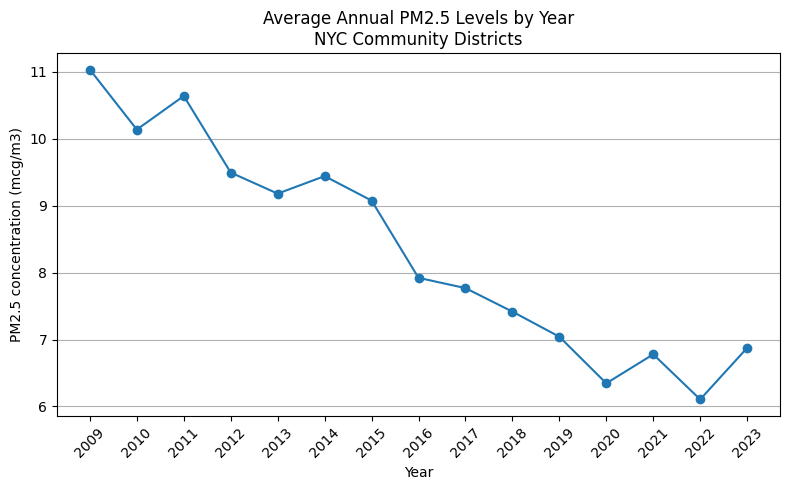

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    year_summary["year"],
    year_summary["mean"],
    marker="o"
)

plt.title("Average Annual PM2.5 Levels by Year\nNYC Community Districts")
plt.xlabel("Year")
plt.ylabel("PM2.5 concentration (mcg/m3)")
plt.xticks(year_summary["year"], rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

The line chart shows a clear downward trend in average PM2.5 levels across New York City community districts from 2009 to the early 2020s.

- Around 2009–2011, average PM2.5 levels were above 10 mcg/m3.
- By the late 2010s and early 2020s, the average had fallen to roughly 6–7 mcg/m3.
- There are year-to-year fluctuations (for example, 2020 looks particularly low, likely related to pandemic-era changes in traffic and activity), but the overall direction is firmly downward.

This supports the first part of the hypothesis: **citywide average PM2.5 has decreased over time**.

## Comparing Early vs. Late Period

In [6]:
all_years = sorted(pm25_cd_annual["year"].unique())
early_years = all_years[:3]   # first three years
late_years = all_years[-3:]   # last three years

early_years, late_years

([np.int64(2009), np.int64(2010), np.int64(2011)],
 [np.int64(2021), np.int64(2022), np.int64(2023)])

In [7]:
def summarize_pm25(data):
    return {
        "mean": data["Data Value"].mean(),
        "median": data["Data Value"].median(),
        "min": data["Data Value"].min(),
        "max": data["Data Value"].max(),
        "std": data["Data Value"].std()
    }

early = pm25_cd_annual[pm25_cd_annual["year"].isin(early_years)]
late = pm25_cd_annual[pm25_cd_annual["year"].isin(late_years)]

inequality_summary = pd.DataFrame(
    {
        "early_period": summarize_pm25(early),
        "late_period": summarize_pm25(late)
    }
)

inequality_summary

,early_period,late_period
mean,10.602486,6.586824
median,10.450000,6.529593
min,7.980000,4.995006
max,16.090000,9.104076
std,1.230208,0.684985


The table comparing the early period and late period summarizes how both the level and spread of PM2.5 changed:

- The **mean** and **median** PM2.5 levels are lower in the late period than in the early period, confirming the citywide improvement.
- The **maximum** PM2.5 (dirtiest districts) drops substantially between the two periods.
- The **standard deviation** (`std`) is lower in the late period, meaning the distribution of PM2.5 values across community districts is more compressed.

In addition to the city getting cleaner overall, **the spread between the cleanest and dirtiest neighborhoods also shrank**, which is evidence in favor of the second part of the hypothesis about inequality.

## Which neighborhoods remain the most polluted?

In [8]:
early_avg_by_cd = (
    early
    .groupby("Geo Place Name")["Data Value"]
    .mean()
    .sort_values(ascending=False)
)

late_avg_by_cd = (
    late
    .groupby("Geo Place Name")["Data Value"]
    .mean()
    .sort_values(ascending=False)
)

top_early = (
    early_avg_by_cd
    .head(5)
    .reset_index()
    .rename(columns={"Data Value": "pm25_mcg_m3"})
)

top_late = (
    late_avg_by_cd
    .head(5)
    .reset_index()
    .rename(columns={"Data Value": "pm25_mcg_m3"})
)

top_early, top_late

(                         Geo Place Name  pm25_mcg_m3
 0                         Midtown (CD5)    15.466667
 1  Stuyvesant Town and Turtle Bay (CD6)    13.443333
 2             Clinton and Chelsea (CD4)    12.533333
 3              Financial District (CD1)    12.486667
 4                 Upper East Side (CD8)    12.303333,
                          Geo Place Name  pm25_mcg_m3
 0                         Midtown (CD5)     8.807413
 1      Greenwich Village and Soho (CD2)     8.321875
 2             Clinton and Chelsea (CD4)     7.907941
 3  Stuyvesant Town and Turtle Bay (CD6)     7.619042
 4              Financial District (CD1)     7.424897)

The two tables above list the five community districts with the highest average PM2.5 levels in:

- the **early period** (first three years in the dataset), and
- the **late period** (most recent three years).

Even though the **absolute PM2.5 values** drop in every neighborhood, some patterns persist:

- Dense, central parts of Manhattan such as **Midtown (CD5)** and nearby districts tend to appear near the top of the ranking in both periods.
- However, the PM2.5 levels in these districts are several mcg/m3 lower in the late period compared to the early period.

This suggests that NYC’s air quality policies and broader changes (for example, cleaner vehicles and fuels) improved conditions citywide, **including the traditionally more polluted core business districts**, even though they still rank among the more polluted neighborhoods relative to others.

## Conclusion and Findings

1. **Citywide PM2.5 levels fell substantially:**  The average PM2.5 concentration across community districts dropped from above 10 mcg/m3 in the late 2000s to roughly 6–7 mcg/m3 in recent years.

2. **Inequality in pollution across neighborhoods narrowed:** The standard deviation of PM2.5 across community districts is lower in the late period than in the early period, and the maximum (dirtiest district) also fell. This means the dirtiest neighborhoods improved faster than the cleanest ones, at least in absolute terms.

3. **But relative rankings are sticky:** Some central, dense areas (for example, Midtown) remain among the most polluted community districts in both periods, even though their absolute pollution levels declined.

Overall, the analysis supports the hypothesis: **NYC community districts became cleaner on average, and the gap between the cleanest and dirtiest districts shrunk over time**, although the relative ordering of “dirtiest” neighborhoods did not fully change.


## Limitations and caveats

- **Descriptive, not causal:** This analysis is purely descriptive. It cannot prove which specific policies or behaviors caused the changes in PM2.5.

- **Focus on PM2.5 only:** The dataset includes other pollutants (NO2, O₃, and asthma-related indicators). Focusing only on PM2.5 ignores other aspects of air quality.

- **Aggregation by year and district:** Using annual averages hides within-year seasonal variation and short-term spikes. It also treats each community district as homogeneous, even though there can be block-level differences.

- **No population weighting:** Each community district is weighted equally in the summary statistics, even though districts differ in population size. A population-weighted analysis could give a more precise picture of exposure.

Despite these limitations, this project shows how relatively simple operations in pandas—filtering, grouping, aggregating, and visualization—can be used to answer a concrete policy-relevant question about environmental inequality in a large real-world dataset.